In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Iman Noor
---
# **Implementation of CNN with TensorFlow/Keras**

In this task, we will create a Convolutional Neural Network (CNN) using TensorFlow and Keras to perform an image classification task. CNNs are a class of deep neural networks that are particularly effective for image data due to their ability to automatically learn spatial hierarchies of features from images.

1. **Define the CNN Architecture**: Construct a sequential CNN model with multiple convolutional layers, activation functions, and pooling layers. The model will consist of:
   - Convolutional layers to extract features from the images.
   - MaxPooling layers to reduce the spatial dimensions.
   - Flatten and Dense layers to perform the final classification.

2. **Compile the Model**: Configure the model with an optimizer, loss function, and evaluation metrics. For binary classification, we typically use the Adam optimizer, binary cross-entropy loss, and accuracy as the metric.

3. **Train the Model**: Fit the model on the training dataset, validate it using a validation set, and monitor the performance. Adjust parameters as needed to optimize the model.

4. **Evaluate the Model**: After training, evaluate the model's performance on a test dataset to measure its accuracy and generalization capabilities.

5. **Make Predictions**: Use the trained model to make predictions on new images and analyze the results.

---
## **Importing libraries**

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import confusion_matrix, classification_report

## **Set Up Paths**

In [3]:
train_dir = '/content/drive/MyDrive/Colab Notebooks/train/train'
test_dir = '/content/drive/MyDrive/Colab Notebooks/test'
val_dir = '/content/drive/MyDrive/Colab Notebooks/validation/validation'

## **Load the Dataset**

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir, batch_size=32, image_size=(224, 224))
test_dataset = tf.keras.utils.image_dataset_from_directory(test_dir, batch_size=32, image_size=(224, 224))

Found 1312 files belonging to 2 classes.
Found 11 files belonging to 2 classes.


In [5]:
# Check the class names to ensure they are correct
print(train_dataset.class_names)  # Should print: ['cats', 'dogs']
print(test_dataset.class_names)

['cats', 'dogs']
['cats', 'dogs']


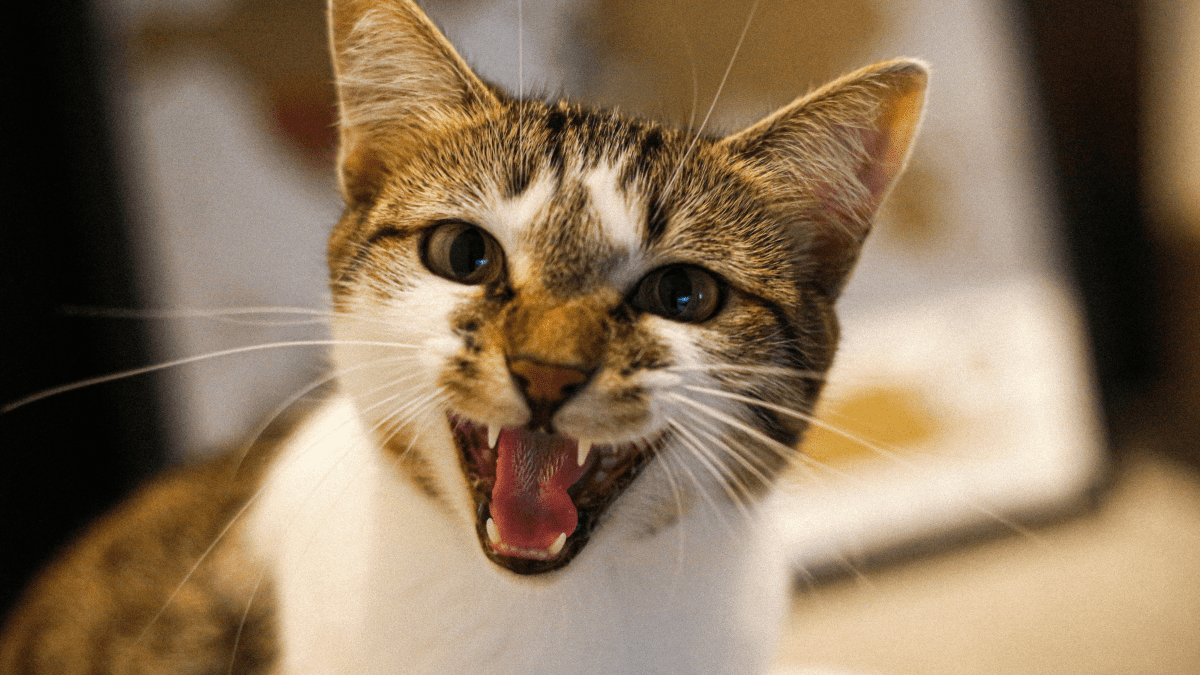

In [6]:
# Let's view an image
from IPython.display import Image
Image('drive/MyDrive/Colab Notebooks/test/cats/cat.png')

## **Preprocessing the data**

In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

n_train_ds = train_dataset.map(lambda x, y: (normalization_layer(x), y))
n_test_ds = test_dataset.map(lambda x, y: (normalization_layer(x), y))

## **Build the CNN Model**

In [8]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPool2D(pool_size=2, padding='valid'),
    tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding='valid'),
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding='valid'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       5,537,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,631,169 (21.48 MB)

 Trainable params: 5,631,169 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    n_train_ds,
    epochs=50,
    batch_size=32,
    # callbacks=[
    #     tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    # ]
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step - accuracy: 0.5358 - loss: 0.7147 - precision: 0.4783 - recall: 0.3821
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.6165 - loss: 0.6778 - precision: 0.6271 - recall: 0.4281
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.6365 - loss: 0.6498 - precision: 0.6771 - recall: 0.3904
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.6453 - loss: 0.6247 - precision: 0.6816 - recall: 0.4280
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.6686 - loss: 0.5959 - precision: 0.6464 - recall: 0.5600
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.7214 - loss: 0.5604 - precision: 0.7315 - recall: 0.5922
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.7154 - loss: 0.5493 - precision: 0.7450 - recall: 0.5982
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.7817 - loss: 0.4867 - precision: 0.7851 - recall: 0.7233
Epoch 9/50
4

## **Model Accuracy and Loss**

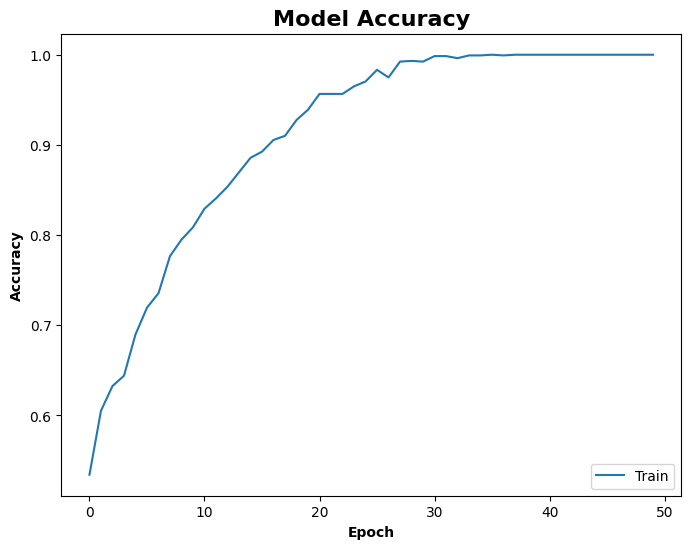

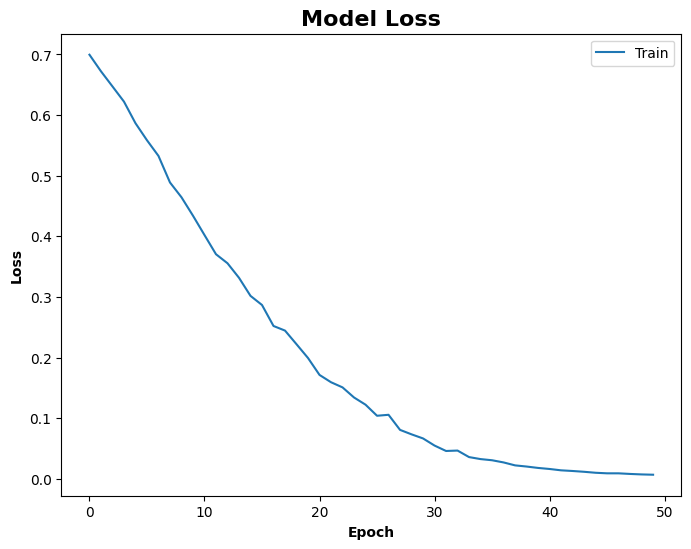

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy', weight='bold', fontsize=16)
plt.ylabel('Accuracy', weight='bold')
plt.xlabel('Epoch', weight='bold')
plt.legend(['Train'], loc='lower right')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'])
plt.title('Model Loss', weight='bold', fontsize=16)
plt.ylabel('Loss', weight='bold')
plt.xlabel('Epoch', weight='bold')
plt.legend(['Train'], loc='upper right')
plt.show();

In [13]:
results = model.evaluate(test_dataset)
test_loss, test_accuracy, test_precision, test_recall = results

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5455 - loss: 545.6097 - precision: 0.5000 - recall: 0.8000


In [14]:
# Extract true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


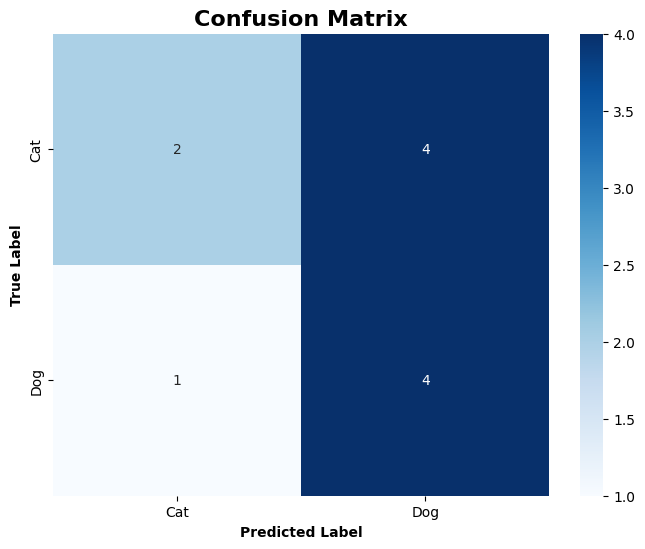

In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label', weight='bold')
plt.ylabel('True Label', weight='bold')
plt.title('Confusion Matrix', weight='bold', fontsize=16)
plt.show();

In [16]:
report = classification_report(y_true, y_pred, target_names=['Cat', 'Dog'])
print(report)

              precision    recall  f1-score   support

         Cat       0.67      0.33      0.44         6
         Dog       0.50      0.80      0.62         5

    accuracy                           0.55        11
   macro avg       0.58      0.57      0.53        11
weighted avg       0.59      0.55      0.52        11



# **The End :)**